# Differentiable Rice-JAX

The step function of Rice-JAX is differentiable. Typically, differentiable RL can be used to optimize the actions of the agents.
However, in the case of RICE-n it could additionally be interesting to see the effect of certain parameters on the global system as a whole. 

As an example, below we will analyze the effect of each agent's actions on the global temperature.

We set up a default Rice scenarrio with 3 regions. For this example, we fix the agent "mitigation_rate" and "savings_rate" actions to 5.0. All other actions are fixed to 0.0.


In [1]:
import jax
import jax.numpy as jnp
from rice_jax import BasicClub, OptimalMitigation, Rice
from rice_jax.utils import (
    load_region_yamls,
    i_to_agent_str
)

# Set up the environment
NUM_REGIONS = 3
region_params = load_region_yamls(NUM_REGIONS)
env_settings = {
    "num_regions": NUM_REGIONS,
    "region_params": region_params,
}
env = Rice(**env_settings)
_, state = env.reset(jax.random.PRNGKey(0))

# Sample random actions, then set them all to zero.
random_actions = env.sample_action(jax.random.PRNGKey(1))
fixed_actions = jax.tree.map(lambda x: jnp.zeros_like(x), random_actions)
fixed_actions = jax.tree.map(lambda x: x.astype(jnp.float32), fixed_actions)
for a in range(NUM_REGIONS): 
    # Set each agent's mitigation_rate and savings_rate to 5.0
    fixed_actions[i_to_agent_str(a)]["mitigation_rate"] = jnp.array(5.0)
    fixed_actions[i_to_agent_str(a)]["savings_rate"] = jnp.array(5.0)

Next, we define a function that takes the actions of all agents as the first input (as jax.grad will take the derivative with respect to the first argument). The function excecutes the same actions for a full episode and returns the final global atmospheric temperature.

In [2]:
def fn(actions):
    def step_fn(s, step_idx):
        key = jax.random.PRNGKey(step_idx)
        _, s = env.step(key, s, actions)
        return s, None  
    
    final_state, _ = jax.lax.scan(jax.checkpoint(step_fn), state, jnp.arange(env.episode_length - 1))
    global_atmospheric_temp = final_state["global_temperature"][0]
    return global_atmospheric_temp

fn(fixed_actions)

Array(4.1321125, dtype=float32)

The final temperature rise is `3.7666264`. Let's now take the gradient of this function with respect to the actions.

In [3]:
grads = jax.grad(fn)(fixed_actions)
for a in range(NUM_REGIONS):
    print(f"Region {a} gradient:")
    for action_name in grads[i_to_agent_str(a)].keys():
        print(f"  {action_name}: {grads[i_to_agent_str(a)][action_name]}")

Region 0 gradient:
  export_limit: 0.0
  import_bid: [0. 0. 0.]
  import_tariff: [0. 0. 0.]
  mitigation_rate: -0.19786542654037476
  savings_rate: 0.07619129866361618
Region 1 gradient:
  export_limit: 0.0
  import_bid: [0. 0. 0.]
  import_tariff: [0. 0. 0.]
  mitigation_rate: -0.07314140349626541
  savings_rate: 0.02909059077501297
Region 2 gradient:
  export_limit: 0.0
  import_bid: [0. 0. 0.]
  import_tariff: [0. 0. 0.]
  mitigation_rate: -0.04788375273346901
  savings_rate: 0.018249912187457085


Only the mitigation_rate and savings_rate have an effect on the global temperature. Let's verify our result by increasing the mitigation_rate action of region 0 by 1; we should observe a decrease in the global temperature of ~`0.20`.

In [4]:
altered_fixed_actions = fixed_actions.copy()
altered_fixed_actions[i_to_agent_str(0)]["mitigation_rate"] = jnp.array(6.0)

fn(altered_fixed_actions)


Array(3.9288192, dtype=float32)

✅

# Differentiable damage parameter

Default final temp: 4.87003231048584
0 dmg final temp: 4.9007487297058105


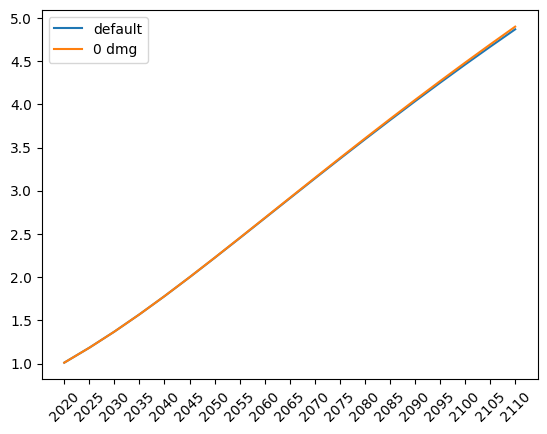

Array(-0.04216681, dtype=float32, weak_type=True)

In [38]:
import jax
import jax.numpy as jnp
from rice_jax import BasicClub, OptimalMitigation, Rice
from rice_jax.utils import (
    load_region_yamls,
    i_to_agent_str
)
import optax
import matplotlib.pyplot as plt

def setup_environment(dmg_parameter):
    NUM_REGIONS = 3
    region_params = load_region_yamls(NUM_REGIONS)
    region_params.xa_updated = dmg_parameter # <-- change damage parameter'
    env = Rice(
        num_regions=NUM_REGIONS,
        region_params=region_params,
        dmg_function="updated" # <-- Use 'updated' damage function
    )
    return env

def step_env(env: Rice,seed: int, state: dict, actions: dict):
    key = jax.random.PRNGKey(seed)
    timestep, new_state = env.step(key, state, actions)
    return new_state, new_state

def get_actions(env: Rice):
    """ A function that returns fixed actions for all agents. """
    # Sample random actions, then set them all to zero.
    actions = env.sample_action(jax.random.PRNGKey(1))
    actions = optax.tree.zeros_like(actions)
    for a in range(env.num_regions): 
        # Set each agent's mitigation_rate and savings_rate to a fixed value
        actions[i_to_agent_str(a)]["mitigation_rate"] = jnp.array(0.0)
        actions[i_to_agent_str(a)]["savings_rate"] = jnp.array(2.5)
    return actions

def do_rollout_with_dmg_parameter(dmg_parameter, *, output_all_states: bool = False):
    """
    output_all_states: If True, return a tuple of (global_atmospheric_temp, stack_of_states)
    This should be false when using jax.grad, because a grad transformed function is 
    expected to output a single value.
    Enabling this option allows us to plot the values through time.
    """
    env = setup_environment(dmg_parameter)
    actions = get_actions(env)
    _, state = env.reset(jax.random.PRNGKey(0))
    final_state, stack_of_states = jax.lax.scan(
        lambda s, i: step_env(env, i, s, actions),
        state,
        jnp.arange(env.episode_length - 1)
    )
    
    # Change to any state variable as a target:
    global_atmospheric_temp = final_state["global_temperature"][0]
    if output_all_states:
        return global_atmospheric_temp, stack_of_states
    return global_atmospheric_temp


final_temp_default, states_default = do_rollout_with_dmg_parameter(0.7438, output_all_states=True)
final_temp_0_dmg, states_0_dmg = do_rollout_with_dmg_parameter(0.0, output_all_states=True)
print(f"Default final temp: {final_temp_default}")
print(f"0 dmg final temp: {final_temp_0_dmg}")

# Plot the two scenarios
plt.plot(jnp.array([temps[0] for temps in states_default["global_temperature"]]), label="default")
plt.plot(jnp.array([temps[0] for temps in states_0_dmg["global_temperature"]]), label="0 dmg")
plt.legend()
plt.xticks(jnp.arange(0, len(states_default["current_simulation_year"])), states_default["current_simulation_year"])
plt.xticks(rotation=45)
plt.show()

grads_of_dmg_parameter_fn = jax.grad(do_rollout_with_dmg_parameter)
grads_of_dmg_parameter_fn(0.7438)
